In [4]:
# eval/generate_figures.ipynb
# Run all cells in order. Saves 3 PNG files to eval/figures/

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

os.makedirs("figures", exist_ok=True)

# ── Shared style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "font.size":        9,
    "axes.labelsize":   11,
    "axes.titlesize":   11,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "figure.dpi":       300,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

DATASETS = ["Natural\nQuestions", "TriviaQA", "SQuAD 2.0", "ASQA", "BioASQ12b"]
DATASETS_SHORT = ["NQ", "TriviaQA", "SQuAD 2.0", "ASQA", "BioASQ12b"]

CLR_PARAM  = "#E6A817"   # amber  — parametric
CLR_VECTOR = "#1A6B8A"   # steel blue — vector
CLR_VLESS  = "#2D6A4F"   # forest green — vectorless
CLR_AV     = "#AABCC8"   # light grey — always-vector baseline
CLR_AVL    = "#5E7387"   # slate grey — always-vectorless baseline
CLR_DDAR   = "#0C3547"   # deep ink blue — DDAR

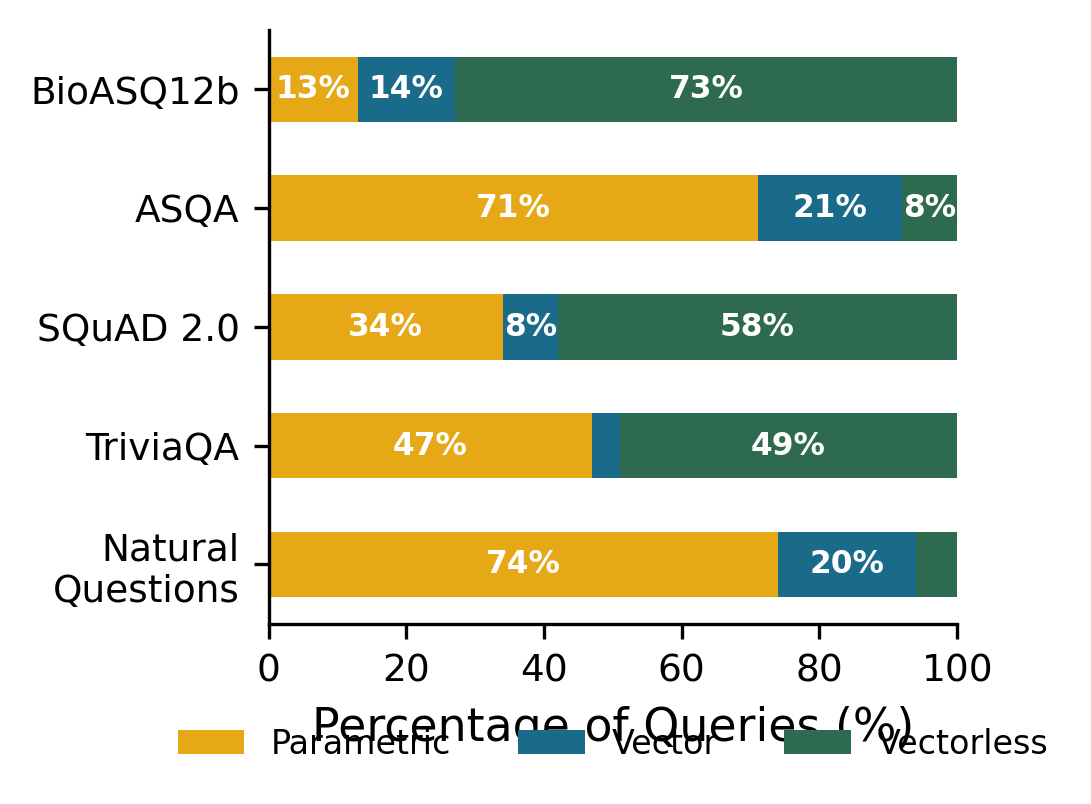

Saved: figures/fig2_routing_distribution.png


In [5]:
# ── Figure 1: Routing Distribution ───────────────────────────────────────────

parametric  = [74, 47, 34, 71, 13]
vector      = [20,  4,  8, 21, 14]
vectorless  = [ 6, 49, 58,  8, 73]

fig, ax = plt.subplots(figsize=(3.5, 2.8))

y = np.arange(len(DATASETS))
bar_h = 0.55

p1 = ax.barh(y, parametric,  height=bar_h, color=CLR_PARAM,  label="Parametric")
p2 = ax.barh(y, vector,      height=bar_h, left=parametric,
             color=CLR_VECTOR, label="Vector")
p3 = ax.barh(y, vectorless,  height=bar_h,
             left=[parametric[i]+vector[i] for i in range(5)],
             color=CLR_VLESS,  label="Vectorless")

# Add percentage labels inside segments if wide enough
for i, (pa, ve, vl) in enumerate(zip(parametric, vector, vectorless)):
    if pa >= 8:
        ax.text(pa/2,           i, f"{pa}%",    ha="center", va="center",
                fontsize=7.5, color="white", fontweight="bold")
    if ve >= 8:
        ax.text(pa + ve/2,      i, f"{ve}%",    ha="center", va="center",
                fontsize=7.5, color="white", fontweight="bold")
    if vl >= 8:
        ax.text(pa + ve + vl/2, i, f"{vl}%",    ha="center", va="center",
                fontsize=7.5, color="white", fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels(DATASETS, fontsize=9)
ax.set_xlabel("Percentage of Queries (%)")
ax.set_xlim(0, 100)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.28),
          ncol=3, frameon=False, fontsize=8)
ax.axvline(x=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.savefig("figures/fig2_routing_distribution.png")
plt.show()
print("Saved: figures/fig2_routing_distribution.png")

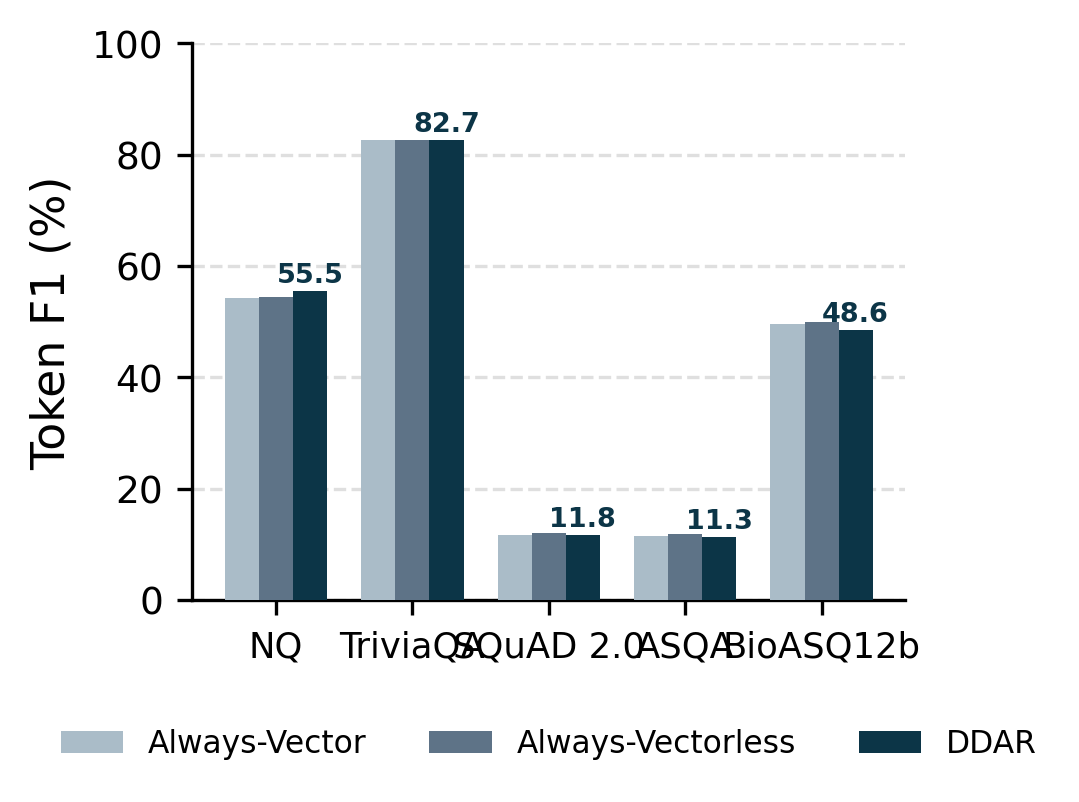

Saved: figures/fig3_answer_quality.png


In [6]:
# ── Figure 2: Answer Quality (Token F1) ───────────────────────────────────────

f1_av   = [54.20, 82.67, 11.78, 11.44, 49.64]
f1_avl  = [54.45, 82.70, 12.01, 11.90, 49.96]
f1_ddar = [55.47, 82.67, 11.78, 11.31, 48.59]

x    = np.arange(len(DATASETS_SHORT))
w    = 0.25

fig, ax = plt.subplots(figsize=(3.5, 2.8))

b1 = ax.bar(x - w,     f1_av,   width=w, color=CLR_AV,   label="Always-Vector",     zorder=3)
b2 = ax.bar(x,         f1_avl,  width=w, color=CLR_AVL,  label="Always-Vectorless",  zorder=3)
b3 = ax.bar(x + w,     f1_ddar, width=w, color=CLR_DDAR, label="DDAR",               zorder=3)

# Value labels above DDAR bars only
for bar in b3:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            f"{h:.1f}", ha="center", va="bottom", fontsize=6.5, color=CLR_DDAR,
            fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(DATASETS_SHORT, fontsize=8.5)
ax.set_ylabel("Token F1 (%)")
ax.set_ylim(0, 100)
ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18),
          ncol=3, frameon=False, fontsize=7.5)

plt.tight_layout()
plt.savefig("figures/fig3_answer_quality.png")
plt.show()
print("Saved: figures/fig3_answer_quality.png")

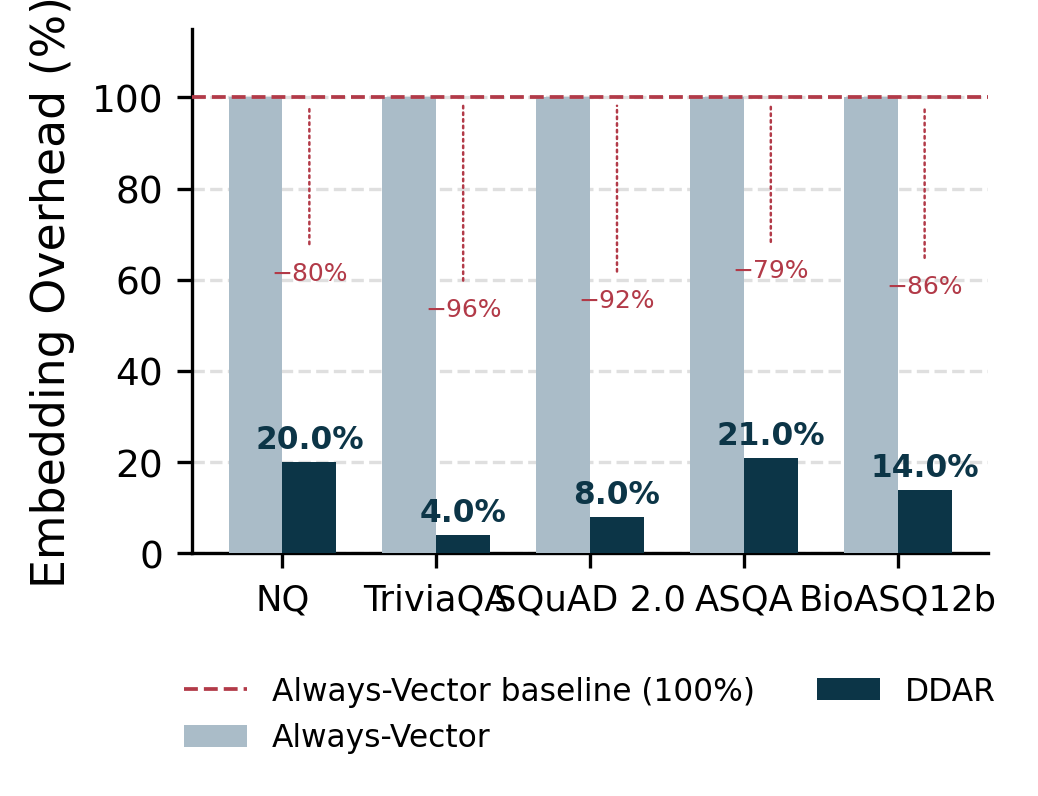

Saved: figures/fig4_embedding_overhead.png


In [7]:
# ── Figure 3: Embedding Overhead Reduction ────────────────────────────────────

ddar_eo = [20.0, 4.0, 8.0, 21.0, 14.0]
av_eo   = [100,  100, 100, 100,  100]

x = np.arange(len(DATASETS_SHORT))
w = 0.35

fig, ax = plt.subplots(figsize=(3.5, 2.8))

ax.bar(x - w/2, av_eo,   width=w, color=CLR_AV,   label="Always-Vector", zorder=3)
ax.bar(x + w/2, ddar_eo, width=w, color=CLR_DDAR, label="DDAR",          zorder=3)

# Dashed baseline at 100
ax.axhline(y=100, color="#B23A48", linestyle="--", linewidth=0.9,
           label="Always-Vector baseline (100%)", zorder=4)

# Value labels above DDAR bars
for i, val in enumerate(ddar_eo):
    ax.text(x[i] + w/2, val + 1.5, f"{val}%",
            ha="center", va="bottom", fontsize=7.5,
            color=CLR_DDAR, fontweight="bold")

# Reduction annotations — draw an arrow from top of DDAR bar to 100
for i, val in enumerate(ddar_eo):
    reduction = 100 - val
    ax.annotate(f"−{reduction:.0f}%",
                xy=(x[i] + w/2, 100),
                xytext=(x[i] + w/2, val + (100 - val)/2),
                fontsize=6, color="#B23A48", ha="center",
                arrowprops=dict(arrowstyle="-", color="#B23A48",
                                lw=0.6, linestyle="dotted"))

ax.set_xticks(x)
ax.set_xticklabels(DATASETS_SHORT, fontsize=8.5)
ax.set_ylabel("Embedding Overhead (%)")
ax.set_ylim(0, 115)
ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18),
          ncol=2, frameon=False, fontsize=7.5)

plt.tight_layout()
plt.savefig("figures/fig4_embedding_overhead.png")
plt.show()
print("Saved: figures/fig4_embedding_overhead.png")